# Fase 4 - Interpretabilidad, inferencia y recomendaciones de negocio
## Pregunta B: Optimización de captación para universidades privadas

**Objetivos de esta fase:**
1. Importancia de variables (permutation importance, más fiable que MDI para RF)
2. SHAP values: importancia global y local por clase
3. Análisis de confounders (T_UNIV vs capital socioeconómico)
4. Reflexión correlación vs causalidad
5. Recomendaciones accionables para el equipo de captación

---

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import subprocess, sys
for pkg in ['shap']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score, accuracy_score

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP no disponible')

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


## 2. Carga y reentrenamiento del modelo final

In [3]:
def load_and_preprocess(data_path='../data/raw/EILU_GRAD_2019.csv'):
    TARGET_MAP = {
        '': 'Becario_SinEmpleo', '1': 'Becario_SinEmpleo',
        '2': 'Asalariado_Indefinido', '3': 'Asalariado_Temporal',
        '4': 'Autonomo_Empresario', '5': 'Autonomo_Empresario', '6': 'Autonomo_Empresario',
    }
    FEATURES   = ['SEXO', 'RAMA', 'T_UNIV', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE', 'MOV_IN']
    TARGET_RAW = 'SIT_PRO'
    df = pd.read_csv(data_path, sep='\t', encoding='latin-1', dtype=str, low_memory=False)
    df = df[FEATURES + [TARGET_RAW]].copy()
    df['TARGET'] = (df[TARGET_RAW].fillna('').str.strip()
                    .apply(lambda v: TARGET_MAP.get(v.split('.')[0], np.nan)))
    df = df.dropna(subset=['TARGET'])
    for col in FEATURES:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['UNIV_TIPO'] = df['T_UNIV'].map({1:'Publica',2:'Publica',3:'Privada',4:'Privada'})
    df[['ESTUDIOS_PADRE','ESTUDIOS_MADRE']] = df[['ESTUDIOS_PADRE','ESTUDIOS_MADRE']].replace(9, np.nan)
    FEATURE_COLS = ['SEXO','RAMA','UNIV_TIPO','ESTUDIOS_PADRE','ESTUDIOS_MADRE','MOV_IN']
    return df, df[FEATURE_COLS].copy(), df['TARGET'].copy(), FEATURE_COLS

df, X, y, FEATURE_COLS = load_and_preprocess()
print(f'Dataset: {X.shape[0]:,} registros')

Dataset: 31,651 registros


In [4]:
# Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

ordinal_cols = ['ESTUDIOS_PADRE', 'ESTUDIOS_MADRE']
binary_cols  = ['SEXO', 'MOV_IN']
numeric_cols = ['RAMA']
nominal_cols = ['UNIV_TIPO']

preprocessor = ColumnTransformer(
    transformers=[
        ('ord',
         Pipeline([('imp', SimpleImputer(strategy='median')),
                   ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]),
         ordinal_cols),
        ('num', SimpleImputer(strategy='most_frequent'), binary_cols + numeric_cols),
        ('ohe',
         Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                   ('enc', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))]),
         nominal_cols),
    ], remainder='drop'
)

# Hiperparámetros seleccionados en Fase 3
BEST_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=20,
    min_samples_split=40,
    max_features='sqrt',
)

pipe_final = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(
        **BEST_PARAMS,
        class_weight='balanced_subsample',
        n_jobs=-1, random_state=RANDOM_STATE
    ))
])

pipe_final.fit(X_train, y_train)

f1_test = f1_score(y_test, pipe_final.predict(X_test), average='macro')
print(f'Modelo final reentrenado')
print(f'F1-macro test: {f1_test:.4f}')

Modelo final reentrenado
F1-macro test: 0.3070


In [5]:
# Nombres de features tras el preprocesado
ohe_feats = (pipe_final.named_steps['prep']
             .named_transformers_['ohe']
             .named_steps['enc']
             .get_feature_names_out(nominal_cols).tolist())
feature_names = ordinal_cols + binary_cols + numeric_cols + ohe_feats
print('Features del modelo:', feature_names)

Features del modelo: ['ESTUDIOS_PADRE', 'ESTUDIOS_MADRE', 'SEXO', 'MOV_IN', 'RAMA', 'UNIV_TIPO_Publica']


In [6]:
# Permutation importance
X_test_prep = pipe_final.named_steps['prep'].transform(X_test)

perm_imp = permutation_importance(
    pipe_final.named_steps['clf'],
    X_test_prep, y_test,
    n_repeats=20,                   
    scoring='f1_macro',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

fi_perm = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': perm_imp.importances_mean,
    'Std':        perm_imp.importances_std,
}).sort_values('Importance', ascending=False)

print('Permutation importance (F1-macro)')
print(fi_perm.round(4).to_string(index=False))

Permutation importance (F1-macro)
          Feature  Importance    Std
             RAMA      0.0552 0.0044
             SEXO      0.0206 0.0033
           MOV_IN      0.0147 0.0026
   ESTUDIOS_MADRE      0.0113 0.0034
UNIV_TIPO_Publica      0.0110 0.0026
   ESTUDIOS_PADRE      0.0080 0.0024


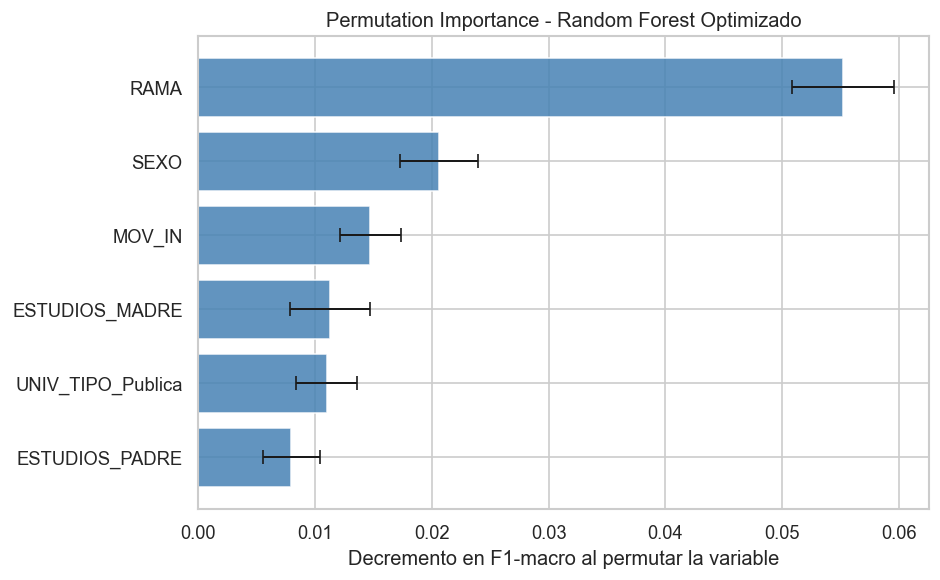

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
fi_sorted = fi_perm.sort_values('Importance', ascending=True)
ax.barh(fi_sorted['Feature'], fi_sorted['Importance'],
        xerr=fi_sorted['Std'], color='steelblue', alpha=0.85,
        error_kw={'elinewidth': 1.2, 'capsize': 4})
ax.set_title('Permutation Importance - Random Forest Optimizado', fontsize=12)
ax.set_xlabel('Decremento en F1-macro al permutar la variable')
plt.tight_layout()
plt.savefig('../outputs/figures/14_permutation_importance.png', bbox_inches='tight')
plt.show()

## 4. MDI (Gini) como comparativa

In [8]:
fi_mdi = pd.DataFrame({
    'Feature':    feature_names,
    'MDI':        pipe_final.named_steps['clf'].feature_importances_,
}).sort_values('MDI', ascending=False)

print('Importancia MDI (Gini)')
print(fi_mdi.round(4).to_string(index=False))
print()

Importancia MDI (Gini)
          Feature    MDI
             RAMA 0.3172
   ESTUDIOS_MADRE 0.1980
   ESTUDIOS_PADRE 0.1925
             SEXO 0.1227
           MOV_IN 0.0979
UNIV_TIPO_Publica 0.0716



## 5. SHAP Values - importancia global por clase

In [9]:
if SHAP_AVAILABLE:
    X_test_df = pd.DataFrame(X_test_prep, columns=feature_names)

    explainer = shap.TreeExplainer(pipe_final.named_steps['clf'])

    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(len(X_test_df), min(2000, len(X_test_df)), replace=False)
    X_sample = X_test_df.iloc[idx].reset_index(drop=True)

    shap_values = explainer.shap_values(X_sample)
    class_names = pipe_final.named_steps['clf'].classes_
    print(f'SHAP calculados  — {len(class_names)} clases')
    print('Clases:', list(class_names))
else:
    print('SHAP no disponible')

SHAP calculados  — 4 clases
Clases: ['Asalariado_Indefinido', 'Asalariado_Temporal', 'Autonomo_Empresario', 'Becario_SinEmpleo']


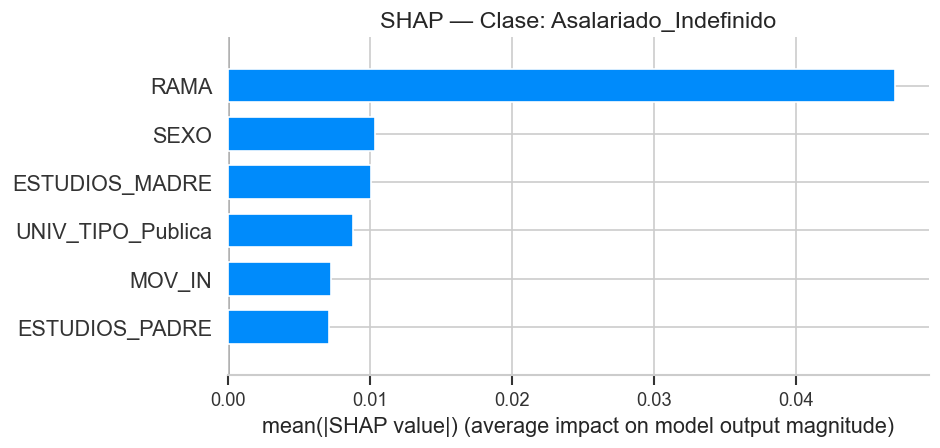

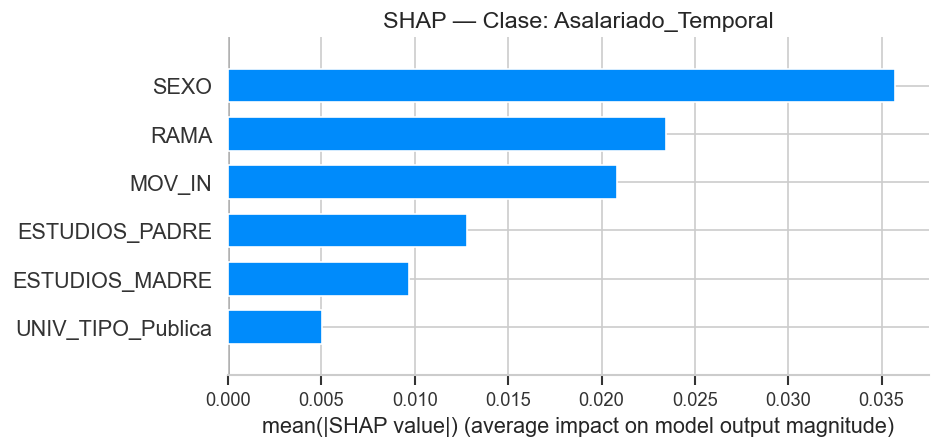

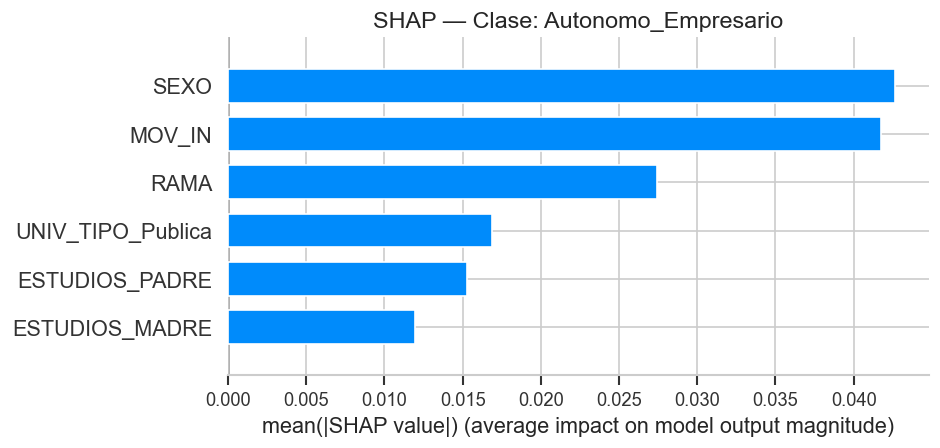

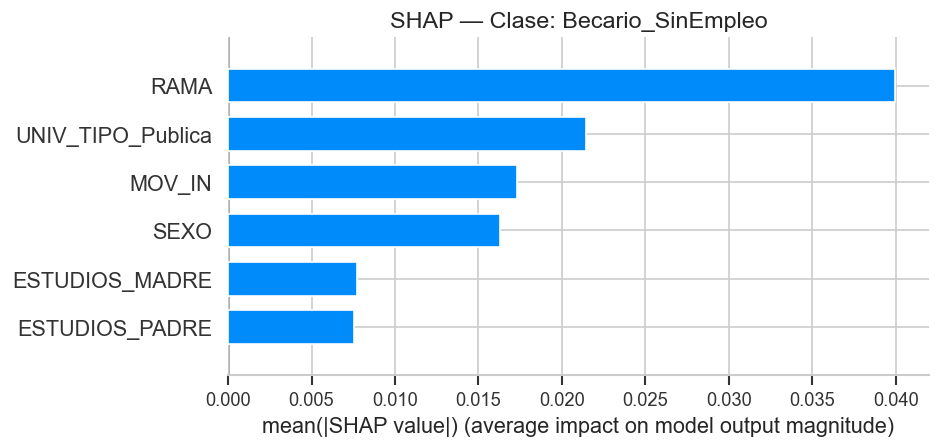

In [10]:
if SHAP_AVAILABLE:

    for i, cls in enumerate(class_names):

        sv = shap_values[i] if isinstance(shap_values, list) else shap_values[:, :, i]

        if sv.shape[1] != X_sample.shape[1]:
            sv = sv[:, :X_sample.shape[1]]

        plt.figure(figsize=(10, 6))

        shap.summary_plot(
            sv,
            X_sample,
            feature_names=feature_names,
            plot_type='bar',
            show=False,
            max_display=8
        )

        plt.title(f'SHAP — Clase: {cls}', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'../outputs/figures/15_shap_clase_{cls}.png', bbox_inches='tight')
        plt.show()

## 6. SHAP Beeswarm - efecto direccional por clase

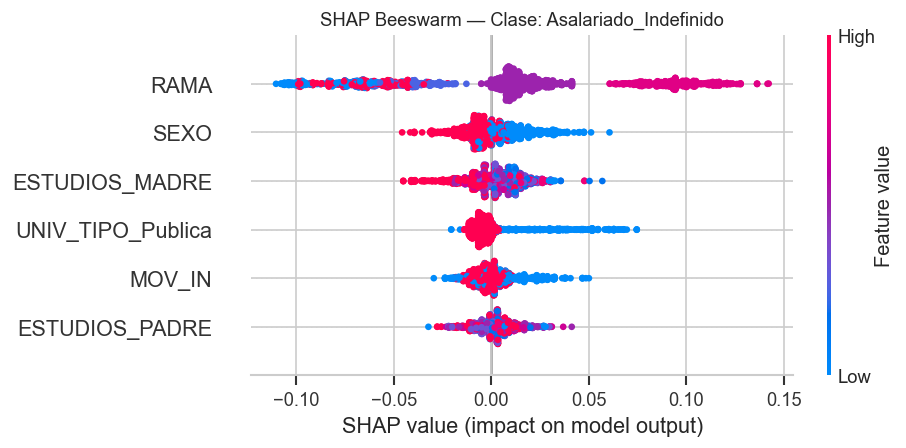

Generado para clase: Asalariado_Indefinido


<Figure size 768x576 with 0 Axes>

Generado para clase: Asalariado_Indefinido


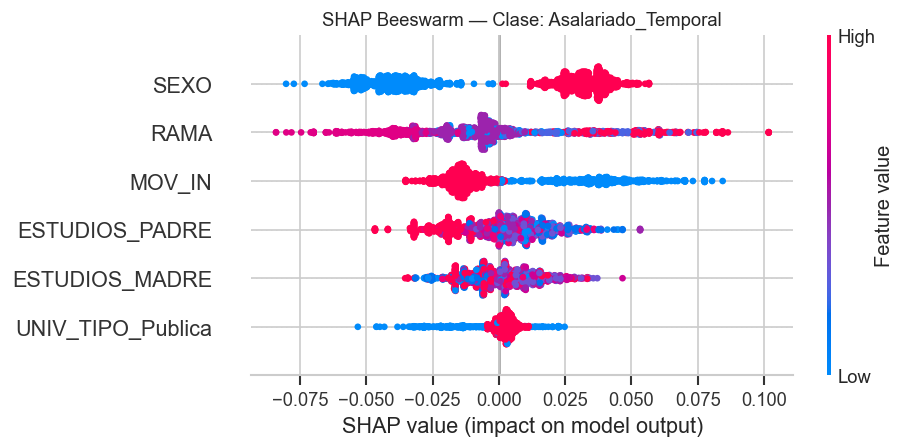

Generado para clase: Asalariado_Temporal


<Figure size 768x576 with 0 Axes>

Generado para clase: Asalariado_Temporal


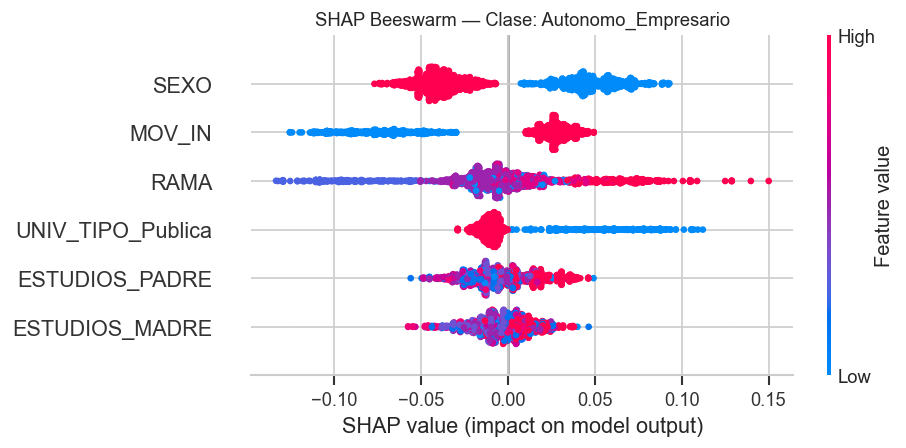

Generado para clase: Autonomo_Empresario


<Figure size 768x576 with 0 Axes>

Generado para clase: Autonomo_Empresario


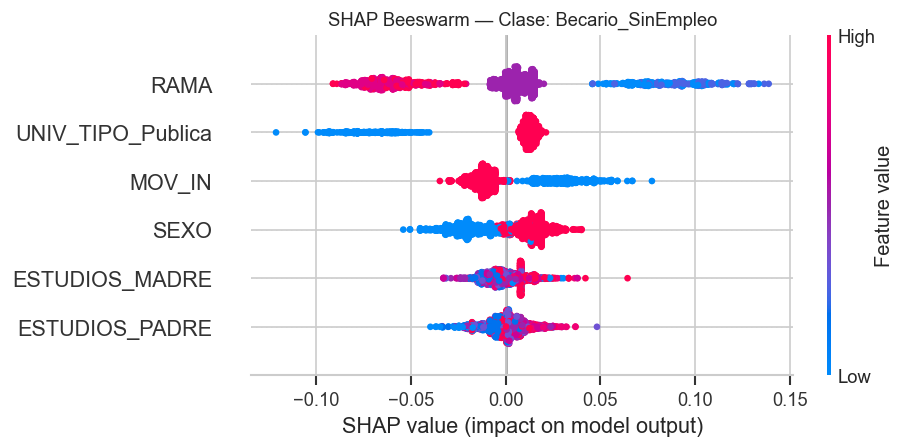

Generado para clase: Becario_SinEmpleo


<Figure size 768x576 with 0 Axes>

Generado para clase: Becario_SinEmpleo


In [11]:
if SHAP_AVAILABLE:
    for i, cls in enumerate(class_names):

        # Extraemos SHAP de forma robusta 
        if isinstance(shap_values, list):
            sv = shap_values[i]              
            base_values = explainer.expected_value[i]
        else:
            sv = shap_values[:, :, i]        
            base_values = explainer.expected_value

        # Asegurmos las dimensiones correctas 
        if sv.shape[1] != X_sample.shape[1]:
            sv = sv[:, :X_sample.shape[1]]

        shap_exp = shap.Explanation(
            values=sv,
            base_values=base_values,
            data=X_sample.values,
            feature_names=feature_names
        )

        # Gráfico
        plt.figure(figsize=(9, 5))
        shap.summary_plot(
            shap_exp,
            plot_type='dot',
            show=False,
            max_display=8
        )

        plt.title(f'SHAP Beeswarm — Clase: {cls}', fontsize=11)
        plt.tight_layout()
        plt.savefig(
            f'../outputs/figures/15b_shap_beeswarm_{cls}.png',
            bbox_inches='tight'
        )
        plt.show()
        plt.close()

        print(f'Generado para clase: {cls}')
        plt.savefig(f'../outputs/figures/15b_shap_beeswarm_{cls}.png', bbox_inches='tight')
        plt.show()
        plt.close()
        print(f'Generado para clase: {cls}')

## 7. SHAP Waterfall — predicción individual

PREDICCIÓN INDIVIDUAL
Perfil: Mujer | RAMA=4 (Ing./Arq.) | Universidad Privada | Padres universitarios | Con movilidad
Clase predicha: Asalariado_Indefinido
Probabilidades:
  Asalariado_Indefinido         : 0.379
  Asalariado_Temporal           : 0.236
  Autonomo_Empresario           : 0.184
  Becario_SinEmpleo             : 0.201


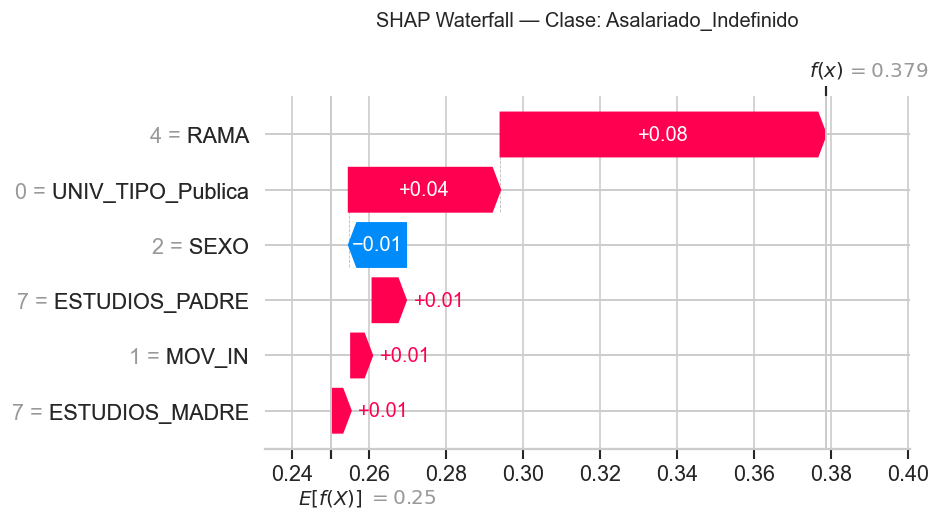

In [12]:
if SHAP_AVAILABLE:
    # Perfil de ejemplo: Mujer · Ingeniería y Arquitectura (RAMA=4) · Privada · Padres universitarios · Movilidad
    ejemplo = pd.DataFrame([{
        'SEXO': 2, 'RAMA': 4, 'UNIV_TIPO': 'Privada',
        'ESTUDIOS_PADRE': 8, 'ESTUDIOS_MADRE': 8, 'MOV_IN': 1
    }])
    ejemplo_prep = pipe_final.named_steps['prep'].transform(ejemplo)
    ejemplo_df   = pd.DataFrame(ejemplo_prep, columns=feature_names)

    shap_ej   = explainer.shap_values(ejemplo_df)
    pred_cls  = pipe_final.predict(ejemplo)[0]
    pred_prob = pipe_final.predict_proba(ejemplo)[0]

    print('PREDICCIÓN INDIVIDUAL')
    print('Perfil: Mujer | RAMA=4 (Ing./Arq.) | Universidad Privada | Padres universitarios | Con movilidad')
    print(f'Clase predicha: {pred_cls}')
    print('Probabilidades:')
    for c, p in zip(class_names, pred_prob):
        print(f'  {c:<30}: {p:.3f}')

    target_idx = list(class_names).index(pred_cls)
    sv_ej = shap_ej[target_idx] if isinstance(shap_ej, list) else shap_ej[:, :, target_idx]
    ev = explainer.expected_value
    ev_scalar = float(ev[target_idx]) if hasattr(ev, '__len__') else float(ev)

    shap_exp_ej = shap.Explanation(
        values       = sv_ej[0].astype(float),
        base_values  = ev_scalar,
        data         = ejemplo_df.values[0],
        feature_names= feature_names
    )
    plt.figure(figsize=(9, 6))
    shap.waterfall_plot(shap_exp_ej, show=False)
    plt.title(f'SHAP Waterfall — Clase: {pred_cls}', fontsize=12, pad=20)
    plt.tight_layout()
    plt.savefig('../outputs/figures/16_shap_waterfall_ejemplo.png', bbox_inches='tight')
    plt.show()
    plt.close()

## 8. Análisis de confounders: ¿T_UNIV o capital socioeconómico?

In [ ]:
# Padres con estudios universitarios
df_a = df[['UNIV_TIPO','ESTUDIOS_PADRE','ESTUDIOS_MADRE','TARGET']].copy()
df_a['CAPITAL_ALTO'] = (
    df_a['ESTUDIOS_PADRE'].isin([7, 8]) | df_a['ESTUDIOS_MADRE'].isin([7, 8])
).astype(int)

tab_cf = pd.crosstab(df_a['UNIV_TIPO'], df_a['CAPITAL_ALTO'], normalize='index') * 100
tab_cf.columns = ['Sin capital alto (%)', 'Capital alto (%)']
print('=== Capital socioeconómico por tipo de universidad ===')
print(tab_cf.round(1).to_string())
print()

=== Capital socioeconómico por tipo de universidad ===
           Sin capital alto (%)  Capital alto (%)
UNIV_TIPO                                        
Privada                    45.6              54.4
Publica                    55.5              44.5

Si Privada tiene mucho más capital alto → T_UNIV puede estar capturando el origen familiar.


In [15]:
# Efecto de T_UNIV controlando por el capital socioeconómico
for capital in [0, 1]:
    label = 'Capital alto' if capital == 1 else 'Sin capital alto'
    sub = df_a[df_a['CAPITAL_ALTO'] == capital]
    tab = pd.crosstab(sub['UNIV_TIPO'], sub['TARGET'], normalize='index') * 100
    print(f'\n{label} (n={len(sub):,}):')
    print(tab.round(1).to_string())

print()


Sin capital alto (n=17,110):
TARGET     Asalariado_Indefinido  Asalariado_Temporal  Autonomo_Empresario  Becario_SinEmpleo
UNIV_TIPO                                                                                    
Privada                     57.3                 21.5                 10.1               11.1
Publica                     49.2                 24.8                  6.8               19.2

Capital alto (n=14,541):
TARGET     Asalariado_Indefinido  Asalariado_Temporal  Autonomo_Empresario  Becario_SinEmpleo
UNIV_TIPO                                                                                    
Privada                     53.4                 21.6                 11.8               13.2
Publica                     46.7                 23.8                  8.0               21.5



## 9. Reflexión: CORRELACIÓN vs CAUSALIDAD

### Lo que el modelo SÍ puede afirmar:
- Existe una **asociación estadística robusta** entre el perfil del estudiante (rama, tipo de universidad, capital familiar, sexo, movilidad) y el destino profesional a 5 años del grado.
- El modelo permite **segmentar perfiles** y estimar probabilidades de cada destino: herramienta válida para decisiones de captación.
- `RAMA` es sistemáticamente el predictor más potente (permutation importance y SHAP coinciden).

### Lo que el modelo NO puede afirmar sin diseño experimental:
- Que estudiar en universidad privada *cause* un mejor destino profesional.
- Que la movilidad interprovincial *cause* mayor tasa de empleo indefinido.
- Que los efectos observados se mantengan actualmente.

### Confounders identificados:
1. **Capital socioeconómico familiar** (ESTUDIOS_PADRE/MADRE): afecta tanto a la elección de universidad como al destino profesional.
2. **Rama de conocimiento**: correlacionada con tipo de universidad (Ingeniería y Salud tienen mayor presencia pública).
3. **Género**: correlacionado con rama (segregación por género en las titulaciones).

## 10. Recomendaciones de negocio

1 - RAMA es la palanca principal
Los estudiantes de ingeniería y salud tienen probabilidades significativamente mayores de asalariado indefinido. Las campañas de captación de universidades privadas en estas ramas deben enfatizar las tasas de empleabilidad específicas por titulación.

2 - Efecto propio de la universidad privada en sociales/artes 
Controlando por capital socioeconómico, la universidad privada se asocia con mayor tasa de emprendimiento en ramas de sociales y artes. Argumento de captación específico para esas titulaciones.

3 - Movilidad interprovincial como señal de empleabilidad  
Los estudiantes con MOV_IN=1 muestran mayor probabilidad de empleo indefinido. Las universidades privadas pueden capitalizar su red de contactos nacional como diferenciador frente a la pública.

4 - Segmentación de perfiles de riesgo  
El modelo permite identificar perfiles con alta probabilidad de caer en "Becario_SinEmpleo" al graduarse, permitiendo a la universidad diseñar intervenciones preventivas (mentoring, bolsa de trabajo personalizada).

5 - Capital socioeconómico como amplificador 
Los alumnos de capital familiar alto obtienen mejores resultados independientemente del tipo de universidad. La captación de estos perfiles puede elevar artificialmente el indicador de empleabilidad; la dirección debe ser consciente de este sesgo al interpretar las estadísticas de inserción laboral.